In [13]:
import os
if os.getenv("COLAB_RELEASE_TAG"):
    import subprocess
    subprocess.run('wget https://raw.githubusercontent.com/luigibonati/mlcolvar/main/colab_setup.sh', shell=True)
    cmd = subprocess.run('bash colab_setup.sh TUTORIAL', shell=True, stdout=subprocess.PIPE)
    print(cmd.stdout.decode('utf-8'))

# IMPORT PACKAGES
import torch
import lightning
import numpy as np
import matplotlib.pyplot as plt

# IMPORT HELPER FUNCTIONS
from mlcolvar.utils.plot import muller_brown_potential, plot_isolines_2D, plot_metrics

# Set seed for reproducibility
torch.manual_seed(42)

In [14]:
import pandas as pd
from mlcolvar.utils.io import load_dataframe
from mlcolvar.utils.timelagged import create_timelagged_dataset
from mlcolvar.data import DictModule
import numpy as np


df = load_dataframe('COLVAR_multiT_new',start=10000,stop=100000)
df

,time,lassoCV_node0,lassoCV_node1,ene,ecv.ene,opes.bias,cos1,cos2,cos3,cos4,...,cos16,cos17,cos18,cos19,cos20,cos21,cos22,cos23,cos24,walker
0,10000.000475,0.511703,-0.253596,-78879.757812,-78879.757812,1.042724,0.520001,-0.672802,0.006545,0.286567,...,0.176809,-0.972260,0.258278,-0.593804,0.475183,-0.999938,0.561746,-0.744594,-0.586294,0
1,10001.000475,0.550214,-0.115944,-78533.710938,-78533.710938,-18.394082,0.421429,-0.514286,0.200126,0.353858,...,0.073171,-0.906824,0.208289,-0.560506,0.268421,-0.945360,0.806865,-0.796693,-0.330170,0
2,10002.000475,0.554823,-0.279422,-78540.679688,-78540.679688,-17.790977,0.370502,-0.425185,0.174220,0.141390,...,0.251378,-0.873635,0.270536,-0.702788,0.479490,-0.974760,0.575254,-0.837389,-0.824362,0
3,10003.000475,0.544905,-0.242636,-78403.812500,-78403.812500,-31.144065,0.544711,-0.534037,-0.012031,0.543883,...,0.287117,-0.898562,0.193645,-0.695265,0.267779,-0.945430,0.429987,-0.719244,-0.656717,0
4,10004.000475,0.575028,-0.269823,-77896.109375,-77896.109375,-101.011668,0.653865,-0.527759,0.089258,0.501320,...,0.380540,-0.987396,0.045482,-0.692916,0.260112,-0.952610,0.493558,-0.781989,-0.969473,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89995,99995.004750,0.749335,-0.047664,-78251.609375,-78251.609375,-47.891658,0.539784,0.157627,-0.998899,0.230532,...,0.352440,-0.846881,0.796311,0.504615,-0.932604,-0.886842,0.645128,-0.473563,-0.978172,0
89996,99996.004750,0.788973,-0.047747,-79189.539062,-79189.539062,4.042400,0.349939,0.167120,-0.995292,0.100246,...,-0.149002,-0.707610,0.599343,0.554630,-0.894244,-0.999514,0.535119,-0.803116,-0.991554,0
89997,99997.004750,0.801738,-0.042380,-78413.281250,-78413.281250,-28.832413,0.293343,0.326378,-0.970829,-0.092976,...,-0.032405,-0.700972,0.520995,0.517081,-0.999985,-0.906644,0.230316,-0.788892,-0.952972,0
89998,99998.004750,0.745613,-0.018123,-78382.531250,-78382.531250,-32.163093,0.371315,0.012930,-0.968102,-0.017394,...,0.088119,-0.804610,0.560989,0.372105,-0.860165,-0.877278,0.661999,-0.758790,-0.986794,0


In [15]:
# Select input features
X = df.filter(regex='cos').values
n_input = X.shape[1]

print(X.shape)
print(X)

(90000, 24)
[[ 0.520001 -0.672802  0.006545 ...  0.561746 -0.744594 -0.586294]
 [ 0.421429 -0.514286  0.200126 ...  0.806865 -0.796693 -0.33017 ]
 [ 0.370502 -0.425185  0.17422  ...  0.575254 -0.837389 -0.824362]
 ...
 [ 0.293343  0.326378 -0.970829 ...  0.230316 -0.788892 -0.952972]
 [ 0.371315  0.01293  -0.968102 ...  0.661999 -0.75879  -0.986794]
 [ 0.722978  0.317806 -0.99809  ...  0.500269 -0.852163 -0.998991]]


In [16]:
#------------- PARAMETERS -------------
multicanonical    = True
temp              = 275.
temp0             = 275.
#--------------------------------------

# Calculate inverse temperature
kb=0.008314
beta=1./(kb*temp)
beta0=1./(kb*temp0)

# Extract cvs from df

t = df['time'].values # save time
ene = df['ene'].values.astype(np.float64) # store energy as long double
bias = df.filter(regex='.bias').values.sum(axis=1) # Load *.bias columns and sum them

# Compute log-weights for time reweighting
logweights = beta*bias

if multicanonical:
    ene -= np.mean(ene) #first shift energy by its mean value
    logweights += (beta0-beta)*ene

In [17]:
#------------- PARAMETERS -------------
lag_time = 100.
#--------------------------------------

# create dataset
dataset = create_timelagged_dataset(X,t,lag_time=lag_time,logweights=logweights,progress_bar=True)
#dataset = create_timelagged_dataset(X,t,lag_time=lag_time,progress_bar=True)

# create datamodule (split train valid)
datamodule = DictModule(dataset,lengths=[0.8,0.2],random_split=False,shuffle=False)

datamodule

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 89757/89757 [03:24<00:00, 438.16it/s]
/home/sompriya/.local/lib/python3.10/site-packages/mlcolvar/data/datamodule.py:134: UserWarning: A torch.generator was provided but it is not used with random_split=False
  warnings.warn(


DictModule(dataset -> DictDataset( "data": [179190, 24], "data_lag": [179190, 24], "weights": [179190], "weights_lag": [179190] ),
		     train_loader -> DictLoader(length=0.8, batch_size=0, shuffle=False),
		     valid_loader -> DictLoader(length=0.2, batch_size=0, shuffle=False))

In [18]:
from mlcolvar.cvs import DeepTICA

n_components = 2
nn_layers = [n_input, 16, 12, n_components]
options= {'nn': {'activation': 'shifted_softplus'}}

model = DeepTICA(nn_layers, options=options)
model

DeepTICA(
  (loss_fn): ReduceEigenvaluesLoss()
  (norm_in): Normalization(in_features=24, out_features=24, mode=mean_std)
  (nn): FeedForward(
    (nn): Sequential(
      (0): Linear(in_features=24, out_features=16, bias=True)
      (1): Shifted_Softplus(beta=1, threshold=20)
      (2): Linear(in_features=16, out_features=12, bias=True)
      (3): Shifted_Softplus(beta=1, threshold=20)
      (4): Linear(in_features=12, out_features=2, bias=True)
    )
  )
  (tica): TICA(in_features=2, out_features=2)
)

In [19]:
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from mlcolvar.utils.trainer import MetricsCallback

# define callbacks
metrics = MetricsCallback()
early_stopping = EarlyStopping(monitor="valid_loss", min_delta=1e-3, patience=100)

# define trainer
trainer = lightning.Trainer(callbacks=[metrics, early_stopping],
                     max_epochs=None, logger=None, enable_checkpointing=False)

# fit
torch.set_float32_matmul_precision('medium')
trainer.fit( model, datamodule )

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/sompriya/.local/lib/python3.10/site-packages/lightning/pytorch/loops/utilities.py:72: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name    | Type                  | Params | Mode  | In sizes | Out sizes
---------------------------------------------------------------------------------
0 | loss_fn | ReduceEigenvaluesLoss | 0      | train | ?        | ?        
1 | norm_in | Normalization         | 0      | train | [24]     | [24]     
2 | nn      | FeedForward           | 630    | tra

Sanity Checking: |                                                                                            …

/home/sompriya/.local/lib/python3.10/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |                                                                                                   …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

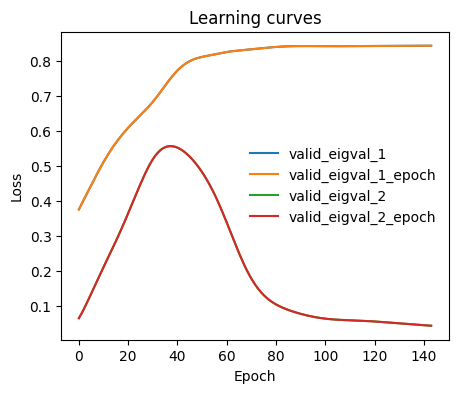

In [20]:
from mlcolvar.utils.plot import plot_metrics

ax = plot_metrics(metrics.metrics,
                  keys=[x for x in  metrics.metrics.keys() if 'valid_eigval' in x],#['train_loss_epoch','valid_loss'],
                  #linestyles=['-.','-'], colors=['fessa1','fessa5'],
                  yscale='linear')

In [21]:
from mlcolvar.core.transform import Normalization
from mlcolvar.core.transform.utils import Statistics

#X = dataset[:]['data']
with torch.no_grad():
    model.postprocessing = None # reset
    s = model(torch.Tensor(X))

norm =  Normalization(n_components, mode='min_max', stats = Statistics(s) )
model.postprocessing = norm

Text(0, 0.5, 'Deep-TICA 2')

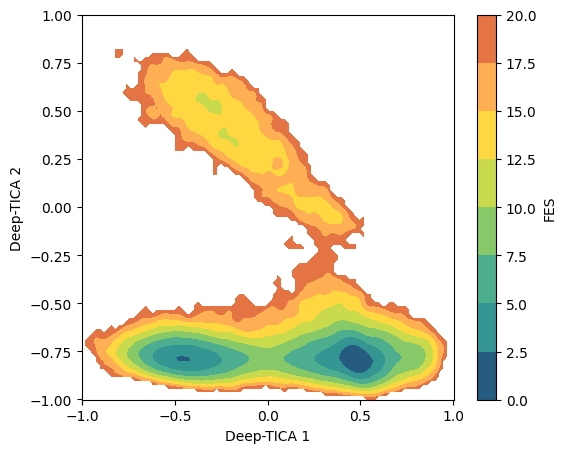

In [22]:
from mlcolvar.utils.fes import compute_fes

fig,ax = plt.subplots(1,1,figsize=(6,5),dpi=100)

# compute cvs
with torch.no_grad():
    s = model(torch.Tensor(X)).numpy()

w = np.exp(logweights)
fes,grid,bounds,error = compute_fes(s,
                                    blocks=1, #weights=w,
                                    bandwidth=0.01, scale_by='range',
                                    plot=True, plot_max_fes=20, ax = ax, eps=1e-8)

ax.set_xlabel('Deep-TICA 1') 
ax.set_ylabel('Deep-TICA 2')
#plt.savefig('Deep_TICA_multiT_aaaa_mod.png',dpi=300,bbox_inches='tight')

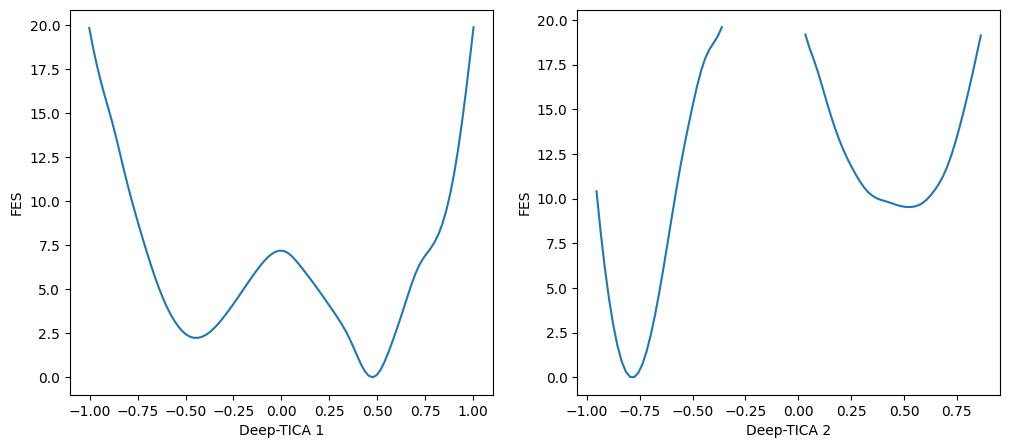

In [23]:
from mlcolvar.utils.fes import compute_fes

fig,axs = plt.subplots(1,n_components,figsize=(6*n_components,5),dpi=100)

for i in range(n_components):
    #w = np.exp(logweights)

    # restrict the second CV to the points in which the first is < 0
    fes,grid,bounds,error = compute_fes(s[:,i] if i == 0 else s[s[:,0] < 0, i ],
                                        #weights=w if i == 0 else w[s[:,0] < 0 ],
                                        blocks=1,
                                        bandwidth=0.02,scale_by='range',
                                        plot=True, plot_max_fes=20, ax = axs[i])
    axs[i].set_xlabel('Deep-TICA '+str(i+1))

In [12]:
## Save the model
x = torch.rand(n_input, dtype=torch.float32, requires_grad=True).unsqueeze(0)
traced_cv = torch.jit.trace ( model, example_inputs=x)
filename='rna_tetra_mutiT_deeptica_aaaa_mod.pt'
traced_cv.save(filename)

/home/sompriya/.local/lib/python3.10/site-packages/mlcolvar/core/nn/utils.py:13: TracerWarning: Converting a tensor to a Python number might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  sp0 = F.softplus(torch.zeros(1), self.beta, self.threshold).item()
/home/sompriya/.local/lib/python3.10/site-packages/torch/jit/_trace.py:165: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at aten/src/ATen/core/TensorBody.h:489.)
  if a.grad is n

In [63]:
#Lasso Regression delete low weitage NN
from sklearn import linear_model
from sklearn.linear_model import LassoCV

with torch.no_grad():
    s = model(torch.Tensor(X)).numpy()
tic0 = s[:,0]#select DeepTICA 1

reg0 = LassoCV(cv=5, random_state=0, max_iter=10000).fit(X, tic0)
print(reg0.coef_)
print(reg0.intercept_)
np.savetxt('tica1_coeff.txt',reg0.coef_,fmt='%0.3f')

[ 0.08323607 -0.0782923   0.0068886  -0.          0.52453241  0.01125082
 -0.         -0.         -0.05610118  0.12269883 -0.0394298  -0.01294365
  0.04051999  0.          0.00198206 -0.         -0.03988362 -0.03906112
 -0.01574269  0.06368067  0.04034217 -0.20326264  0.02604698  0.03137442]
0.2566176197457576


In [64]:
#Lasso Regression delete low weitage NN
from sklearn import linear_model
from sklearn.linear_model import LassoCV

with torch.no_grad():
    s = model(torch.Tensor(X)).numpy()
tic1 = s[:,1]#select DeepTICA 2

reg1 = LassoCV(cv=5, random_state=0, max_iter=10000).fit(X, tic1)
print(reg1.coef_)
print(reg1.intercept_)
np.savetxt('tica2_coeff.txt',reg1.coef_,fmt='%0.3f')

[ 0.02524     0.02093525 -0.00674056 -0.01204031 -0.0071359   0.02034566
 -0.02550148 -0.00371049 -0.          0.04715709 -0.0265244   0.
 -0.01208544  0.02777132  0.01852334  0.00882883  0.17727176 -0.07900743
  0.03540476  0.03258563  0.19254106 -0.64475899 -0.03346205  0.01396601]
-0.006130836551342278


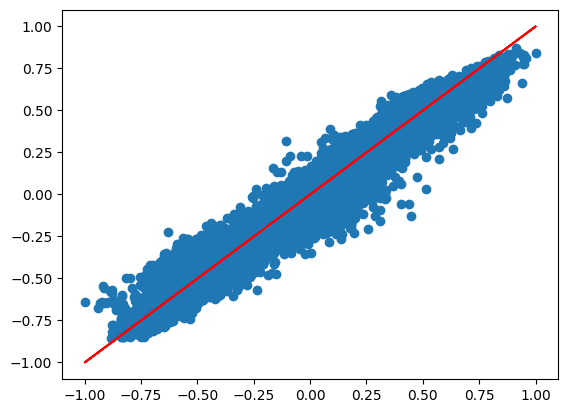

In [65]:
X_np = torch.Tensor(X).numpy()
ypred = reg0.predict(X)

plt.scatter(tic0,ypred)
plt.plot(tic0,tic0,c='r') # X axis=DeepTICA 1 CV, Y axis= lassoCV, 

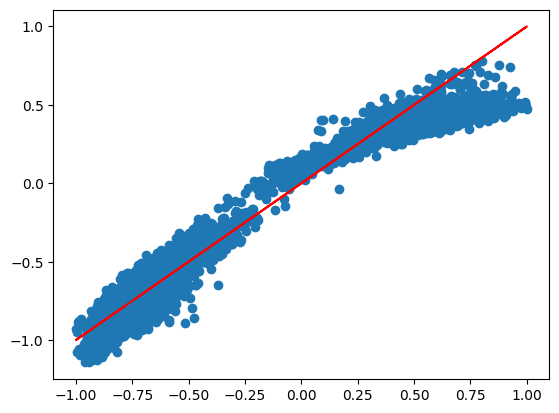

In [66]:
X_np = torch.Tensor(X).numpy()
ypred = reg1.predict(X)

plt.scatter(tic1,ypred)
plt.plot(tic1,tic1,c='r') # X axis=DeepTICA 2 CV, Y axis= lassoCV, 

In [67]:
s='lasso_node0: COMBINE ARG='
for i in range(len(reg0.coef_)):
    if reg0.coef_[i] != 0:
        s+= 'cos%d'%(i+1)
        if i < len(reg0.coef_) - 1:
            s+= ','
s+= ' COEFFICIENTS='

for i in range(len(reg0.coef_)):
    if reg0.coef_[i] != 0:
        s+= '%0.4f'%reg0.coef_[i]
        if i < len(reg0.coef_) - 1:
            s+= ','
s+= ' PERIODIC=NO'
print(s)
print(' ')

#correct for offset
of_arr = ypred - np.dot(X_np,reg0.coef_)
offset = reg0.intercept_
if offset>0:
    s2 = 'lassoCV_node0: MATHEVAL ARG=lasso_node0 FUNC=x+%0.4f PERIODIC=NO'%offset
elif offset<0:
    s2 = 'lassoCV_node0: MATHEVAL ARG=lasso_node0 FUNC=x%0.4f PERIODIC=NO'%offset
print(s2)

lasso_node0: COMBINE ARG=cos1,cos2,cos3,cos5,cos6,cos9,cos10,cos11,cos12,cos13,cos15,cos17,cos18,cos19,cos20,cos21,cos22,cos23,cos24 COEFFICIENTS=0.0832,-0.0783,0.0069,0.5245,0.0113,-0.0561,0.1227,-0.0394,-0.0129,0.0405,0.0020,-0.0399,-0.0391,-0.0157,0.0637,0.0403,-0.2033,0.0260,0.0314 PERIODIC=NO
 
lassoCV_node0: MATHEVAL ARG=lasso_node0 FUNC=x+0.2566 PERIODIC=NO


In [68]:
s='lasso_node1: COMBINE ARG='
for i in range(len(reg1.coef_)):
    if reg1.coef_[i] != 0:
        s+= 'cos%d'%(i+1)
        if i < len(reg1.coef_) - 1:
            s+= ','
s+= ' COEFFICIENTS='

for i in range(len(reg1.coef_)):
    if reg1.coef_[i] != 0:
        s+= '%0.4f'%reg1.coef_[i]
        if i < len(reg1.coef_) - 1:
            s+= ','
s+= ' PERIODIC=NO'
print(s)
print(' ')

#correct for offset
of_arr = ypred - np.dot(X_np,reg1.coef_)
offset = reg1.intercept_
if offset>0:
    s2 = 'lassoCV_node1: MATHEVAL ARG=lasso_node1 FUNC=x+%0.4f PERIODIC=NO'%offset
elif offset<0:
    s2 = 'lassoCV_node1: MATHEVAL ARG=lasso_node1 FUNC=x%0.4f PERIODIC=NO'%offset
print(s2)

lasso_node1: COMBINE ARG=cos1,cos2,cos3,cos4,cos5,cos6,cos7,cos8,cos10,cos11,cos13,cos14,cos15,cos16,cos17,cos18,cos19,cos20,cos21,cos22,cos23,cos24 COEFFICIENTS=0.0252,0.0209,-0.0067,-0.0120,-0.0071,0.0203,-0.0255,-0.0037,0.0472,-0.0265,-0.0121,0.0278,0.0185,0.0088,0.1773,-0.0790,0.0354,0.0326,0.1925,-0.6448,-0.0335,0.0140 PERIODIC=NO
 
lassoCV_node1: MATHEVAL ARG=lasso_node1 FUNC=x-0.0061 PERIODIC=NO
